# Generate Report — Matched Sample (Equal APR / HPR)

Same analysis as `generate_report.ipynb` but with **equal sample sizes**: human fix PRs are randomly sampled to match the number of agent fix PRs.

**Produces:**
- `results/matched_report_figures/` — PNG figures
- `results/matched_report.txt` — text summary with tables

In [1]:
%pip install matplotlib seaborn scipy pyarrow fsspec requests lifelines

Note: you may need to restart the kernel to use updated packages.


## Imports & Setup

In [2]:
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns
from scipy import stats as sp_stats

%matplotlib inline

## Paths

In [3]:
DATA_DIR = Path("data_dec2024_feb2026")
OUT_DIR = Path("results")
FIG_DIR = OUT_DIR / "matched_report_figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

REPORT_PATH = OUT_DIR / "matched_report.txt"

RESULTS_DIR = Path("results")

## Load Data (Fix PRs Only) — Matched Sample

In [4]:
HF_BASE = "https://huggingface.co/datasets/mabujadallah/GitHub-Agentic-PR-Dataset/resolve/main"

print("Loading fix-only data from Hugging Face ...")
all_prs_full = pd.read_parquet(f"{HF_BASE}/fix_prs_only.parquet")
commits_full = pd.read_parquet(f"{HF_BASE}/fix_pr_commits.parquet")
details_full = pd.read_parquet(f"{HF_BASE}/fix_pr_commit_details.parquet",
                               columns=["sha", "pr_id", "filename", "additions", "deletions"])

# Exclude open PRs — only keep closed PRs (merged + closed-unmerged) per Watanabe et al.
all_prs_full = all_prs_full[all_prs_full["state"] == "closed"].copy()

agent_prs_full = all_prs_full[all_prs_full["source"] == "agent"].copy()
human_prs_full = all_prs_full[all_prs_full["source"] == "human"].copy()

print(f"  Full Agent PRs (closed) : {len(agent_prs_full):,}")
print(f"  Full Human PRs (closed) : {len(human_prs_full):,}")

# ── Matched sampling: sample human PRs to match agent PR count ──
SEED = 42
n_agent = len(agent_prs_full)
human_prs_sampled = human_prs_full.sample(n=n_agent, random_state=SEED)

agent_prs = agent_prs_full.copy()
human_prs = human_prs_sampled.copy()
all_prs = pd.concat([agent_prs, human_prs], ignore_index=True)

# Filter commits and details to only matched PR ids
matched_pr_ids = set(all_prs["id"])
commits = commits_full[commits_full["pr_id"].isin(matched_pr_ids)].copy()
details = details_full[details_full["pr_id"].isin(matched_pr_ids)].copy()

print(f"\n  Matched Agent PRs : {len(agent_prs):,}")
print(f"  Matched Human PRs : {len(human_prs):,}")
print(f"  Matched Commits   : {len(commits):,}")
print(f"  Matched Details   : {len(details):,}")
print(f"  Random seed       : {SEED}")

Loading fix-only data from Hugging Face ...
  Full Agent PRs (closed) : 116,011
  Full Human PRs (closed) : 288,689

  Matched Agent PRs : 116,011
  Matched Human PRs : 116,011
  Matched Commits   : 642,861
  Matched Details   : 5,197,987
  Random seed       : 42


In [5]:
print("=== all_prs (matched fix PRs) ===")
display(all_prs.sample(10))

print("\n=== commits ===")
display(commits.sample(10))

print("\n=== details ===")
display(details.sample(10))

=== all_prs (matched fix PRs) ===


,id,number,title,body,user,user_id,state,created_at,closed_at,merged_at,repo_id,repo_url,repo_name,html_url,is_agent,agent,type,source
156259,2942435432,102055,chore(cleanup): Fix File cleanup job timeouts,The File cleanup job was timing out trying to ...,yuvmen,24393774,closed,2025-10-23T23:04:12Z,2025-10-24T18:10:47Z,2025-10-24T18:10:47Z,873328,https://api.github.com/repos/getsentry/sentry,getsentry/sentry,https://github.com/getsentry/sentry/pull/102055,False,human,fix,human
60205,2411556345,22,Fix image loading errors after app restart,This PR fixes the issue where the app crashes ...,devin-ai-integration[bot],158243242,closed,2025-03-22T21:28:49Z,2025-03-23T02:40:42Z,2025-03-23T02:40:42Z,798177525,https://api.github.com/repos/MolasoftLLC/mola-...,MolasoftLLC/mola-ai-flutter-templete,https://github.com/MolasoftLLC/mola-ai-flutter...,True,Devin,fix,agent
89971,3131341161,71,fix(deps): bump the python-minor group across ...,Bumps the python-minor group with 19 updates i...,dependabot[bot],49699333,closed,2025-12-26T15:17:29Z,2026-01-05T12:50:34Z,None,896558371,https://api.github.com/repos/bogdanscarwash/ba...,bogdanscarwash/babylon,https://github.com/percy-raskova/babylon/pull/71,True,Claude_Code,fix,agent
224628,2500132561,3628,ci: fix cilium hubble deployment v1.5,<!-- Thank you for helping Azure Container Net...,camrynl,31013536,closed,2025-05-06T01:01:24Z,2025-05-06T22:22:33Z,2025-05-06T22:22:32Z,53971519,https://api.github.com/repos/Azure/azure-conta...,Azure/azure-container-networking,https://github.com/Azure/azure-container-netwo...,False,human,fix,human
114151,3015396032,11622,fix(deps): update dependency com.squareup.okht...,This PR contains the following updates:\n\n| P...,renovate[bot],29139614,closed,2025-11-16T17:40:20Z,2025-11-16T18:04:06Z,2025-11-16T18:04:06Z,254450741,https://api.github.com/repos/projectnessie/nessie,projectnessie/nessie,https://github.com/projectnessie/nessie/pull/1...,True,Claude_Code,fix,agent
158382,2586867332,19631,Added error forwarding,### Changelog entry <!-- a user-readable short...,xyliganSereja,113226520,closed,2025-06-12T10:38:56Z,2025-06-12T12:27:41Z,2025-06-12T12:27:41Z,456549280,https://api.github.com/repos/ydb-platform/ydb,ydb-platform/ydb,https://github.com/ydb-platform/ydb/pull/19631,False,human,fix,human
72726,2592687787,52,fix: improve mobile responsiveness for contrib...,Fixes mobile screen overflow issues on the con...,bdougie,5713670,closed,2025-06-14T15:25:10Z,2025-06-14T15:32:53Z,2025-06-14T15:32:53Z,967062465,https://api.github.com/repos/bdougie/contribut...,bdougie/contributor.info,https://github.com/bdougie/contributor.info/pu...,True,Claude_Code,fix,agent
165220,3108582595,14060,fix: Add support for extended definition of at...,**Backport:** https://github.com/shopware/shop...,shopware-octo-sts-app-2[bot],243962474,closed,2025-12-17T04:32:15Z,2026-01-06T03:47:05Z,2026-01-06T03:47:05Z,131995661,https://api.github.com/repos/shopware/shopware,shopware/shopware,https://github.com/shopware/shopware/pull/14060,False,human,fix,human
183039,3081985936,245539,"Fix ""now"" and mixed format date handling in sh...",## Summary\r\n\r\nThis PR fixes a bug where mi...,kowalczyk-krzysztof,65892118,closed,2025-12-08T15:01:27Z,2025-12-10T14:12:01Z,2025-12-10T14:12:01Z,7833168,https://api.github.com/repos/elastic/kibana,elastic/kibana,https://github.com/elastic/kibana/pull/245539,False,human,fix,human
79011,2857895590,269,fix(deps): update all dependencies,> [!NOTE]\n> Mend has cancelled [the proposed ...,renovate[bot],29139614,closed,2025-09-24T18:30:18Z,2025-10-06T09:23:57Z,None,978955902,https://api.github.com/repos/robertlinde/next-...,robertlinde/next-nest-turbo-auth-boilerplate,https://github.com/robertlinde/next-nest-turbo...,True,Claude_Code,fix,agent



=== commits ===


,sha,pr_id,author,committer,message
1017370,525bf3843b4648edc9585bf9560a536f55a52a76,2655493395,0x1NotMe,0x1NotMe,refactor: use helper function for detail displ...
1126166,9188673c3854b4c41f6ee73d42941126971c83e0,3090970146,Copilot,Copilot,fix: center sell restriction panel\n\nCo-autho...
582402,f0fcd488b664b1f5fcfa0219d3fec895496ae801,2959854772,AbdulTheActivePiecer,AbdulTheActivePiecer,chore: improve extending dayjs
831854,e8a42a95efd1230f564d8861e9d5ea4ebf2d1f78,3153234760,mvfc,web-flow,Merge branch 'master' into fix/source_klaviyo_...
937312,812b890b3ae0bf20b1811407b1b9d3071ddf9944,2719659567,venubhat23,web-flow,Merge pull request #100 from venubhat23/cursor...
1125817,d2aa17821309b56b1c4f24d0fc20429247dad29c,2592285134,renovate[bot],web-flow,fix(deps): update dependency @openrouter/ai-sd...
21242,70c422f8a3419708dadc52653707617f7e1ae7e1,2912234313,muhammad-ali-e,muhammad-ali-e,replacing .error with .exception in common exc...
865539,1ff4dc39d76ac525d772769fb956cbf7b1bff8fa,3272644757,Dosant,web-flow,Merge branch 'main' into d/2026-02-11-flyout-o...
158497,6267404a48908902072cf36e9ce182aacaf48adb,2492930026,lalalune,lalalune,package updates
388150,3a6be93591cacd33a25e62efca92830de44fee5d,2856229823,devdattatalele,devdattatalele,Address reviewer feedback: refactor line endin...



=== details ===


,sha,pr_id,filename,additions,deletions
7366358,55583510b05cbdad6a73bb757898b3edc13ce0ae,2662019586,Assets/Images/openmoji/shaking_face.svg,17.0,0.0
7134810,70c08ed706ede26f81892d761aa008580ac9eea2,2637412676,ci-test-env/lib/python3.12/site-packages/pygme...,648.0,0.0
6568953,e07d5898a951a752f24e00af442659c991ff69a6,2292936282,tchat/node_modules/logkitty/build/android/Andr...,1.0,0.0
4162899,5487a625341ec3b9fd2923123840648dc263cf74,2698033231,node_modules/firebase/node_modules/@firebase/a...,28.0,0.0
544402,175f492323ef34d990796cb0043caf5ec1c9d47a,2333728087,app/scripts/controller-init/multichain/multich...,13.0,11.0
3736599,45f995347e940ca5ceb8d625a901a424c25b3493,2762114483,.jjconflict-base-0/dafny/benchmarks/dafny-benc...,63.0,0.0
2410301,f92c9e61cf6ce32a5a719c3b30bf07917cf5a029,3024783259,web/src/components/modals/UserFilesModal.tsx,1.0,1.0
6115207,e07d5898a951a752f24e00af442659c991ff69a6,2292936282,mobile/node_modules/ethereum-cryptography/node...,1.0,0.0
6308565,e07d5898a951a752f24e00af442659c991ff69a6,2292936282,tchat/mobile/node_modules/@chainsafe/is-ip/lib...,28.0,0.0
4311878,5bb41d108a89fffc4fb79e879e2bafb647eeed27,2679702092,server/node_modules/side-channel-list/.github/...,12.0,0.0


## Helper Functions

In [6]:
def word_count(text) -> int:
    if not text or not isinstance(text, str):
        return 0
    return len(text.split())


report_lines: list[str] = []

def section(title: str):
    report_lines.append("")
    report_lines.append("=" * 70)
    report_lines.append(f"  {title}")
    report_lines.append("=" * 70)
    print(f"\n{'=' * 70}\n  {title}\n{'=' * 70}")

def out(line: str = ""):
    report_lines.append(line)
    print(line)

## Dataset Overview

In [7]:
section("Dataset Overview (Matched Closed Fix PRs)")
out(f"Date range         : {all_prs['created_at'].min()[:10]} to {all_prs['created_at'].max()[:10]}")
out(f"Total closed fix PRs : {len(all_prs):,}")
out(f"  Agent fix PRs      : {len(agent_prs):,}")
out(f"  Human fix PRs      : {len(human_prs):,}  (randomly sampled to match agent count)")
out(f"Repositories       : {all_prs['repo_name'].nunique():,}")
out(f"Total commits      : {len(commits):,}")
out(f"Unique committers  : {commits['author'].nunique():,}")
out(f"Random seed        : {SEED}")

if "agent" in agent_prs.columns:
    out("\nAgent fix PR breakdown:")
    for agent, cnt in agent_prs["agent"].value_counts().items():
        out(f"  {agent:20s} {cnt:>8,}")


  Dataset Overview (Matched Closed Fix PRs)
Date range         : 2024-12-01 to 2026-02-28
Total closed fix PRs : 232,022
  Agent fix PRs      : 116,011
  Human fix PRs      : 116,011  (randomly sampled to match agent count)
Repositories       : 9,782
Total commits      : 642,861
Unique committers  : 21,663
Random seed        : 42

Agent fix PR breakdown:
  Claude_Code            43,859
  Cursor                 37,055
  Copilot                26,674
  Devin                   8,423


## RQ1 — Fix PR Change Size

**How do Agent fix PRs differ from Human fix PRs in change size?**

In [8]:
section("RQ1: How do Agent fix PRs differ from Human fix PRs in change size?")

# --- Change size metrics from commit details ---
# Aggregate per PR: files changed, lines added, lines deleted
pr_stats = details.groupby("pr_id").agg(
    files_changed=("filename", "nunique"),
    lines_added=("additions", "sum"),
    lines_deleted=("deletions", "sum"),
).reset_index()

agent_ids = set(agent_prs["id"])
human_ids = set(human_prs["id"])

apr_stats = pr_stats[pr_stats["pr_id"].isin(agent_ids)]
hpr_stats = pr_stats[pr_stats["pr_id"].isin(human_ids)]

out("\nChange size (median):")
for metric in ["files_changed", "lines_added", "lines_deleted"]:
    a_med = apr_stats[metric].median() if len(apr_stats) else 0
    h_med = hpr_stats[metric].median() if len(hpr_stats) else 0
    out(f"  {metric:<20s}  APR: {a_med:>8.0f}   HPR: {h_med:>8.0f}")

# --- Description length ---
agent_prs["desc_words"] = agent_prs["body"].apply(word_count)
human_prs["desc_words"] = human_prs["body"].apply(word_count)
out(f"\nPR description length (median words):  APR: {agent_prs['desc_words'].median():.0f}   HPR: {human_prs['desc_words'].median():.0f}")


  RQ1: How do Agent fix PRs differ from Human fix PRs in change size?

Change size (median):
  files_changed         APR:        2   HPR:        2
  lines_added           APR:       36   HPR:       20
  lines_deleted         APR:       11   HPR:        7

PR description length (median words):  APR: 148   HPR: 82


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\2749861254.py:11: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


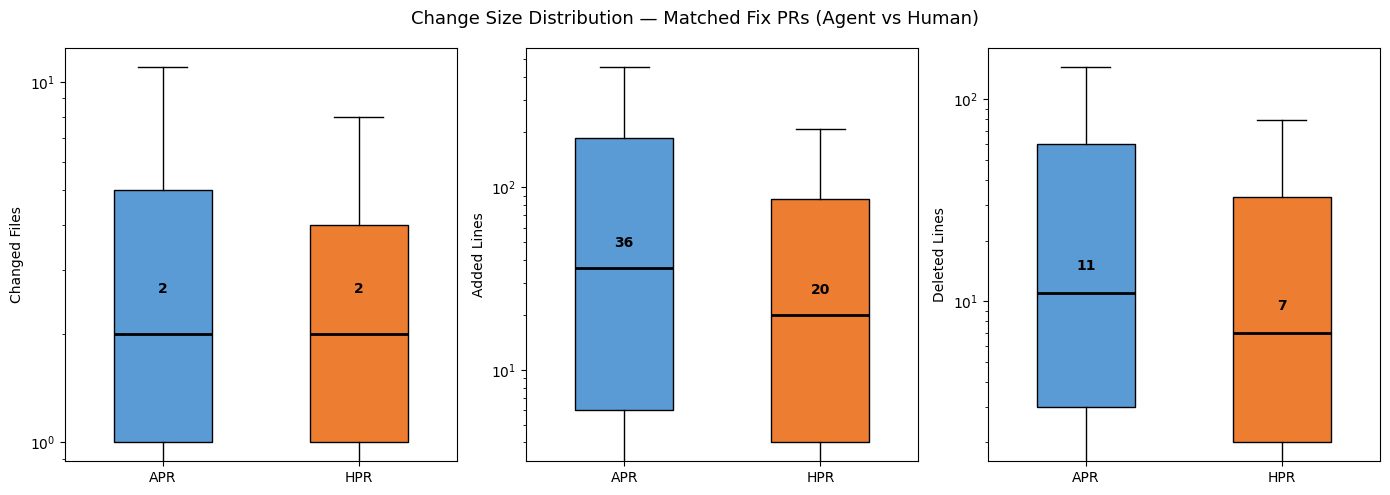

  -> Figure saved: results\matched_report_figures\rq1_change_size.png


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\2749861254.py:48: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_desc, labels=["APR", "HPR"], patch_artist=True,


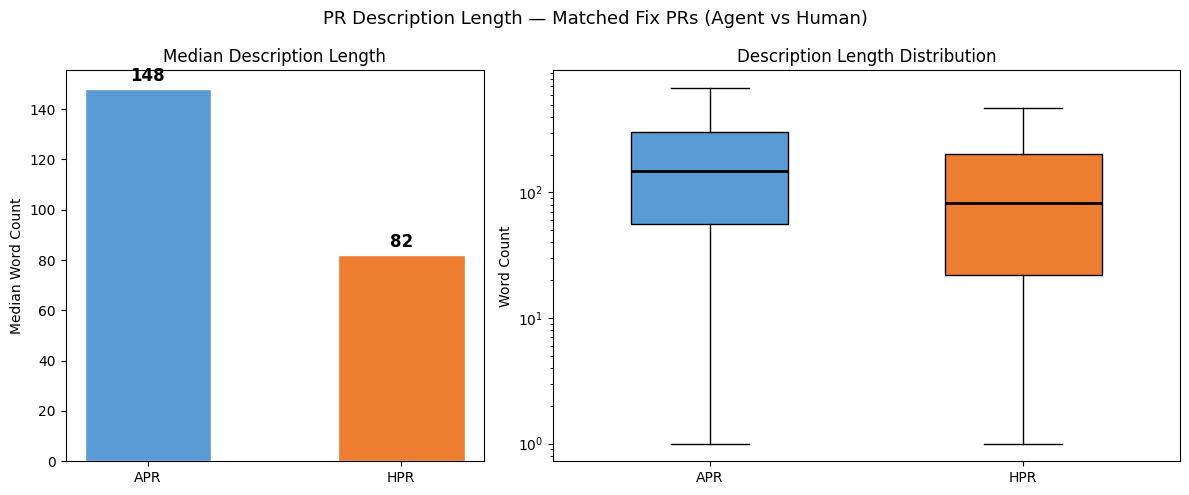

  -> Figure saved: results\matched_report_figures\rq1_description_length.png


In [9]:
# ── Figure 1: Code Change Size — Box plots on log scale ──
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
metrics = ["files_changed", "lines_added", "lines_deleted"]
titles_m = ["Changed Files", "Added Lines", "Deleted Lines"]

for ax, metric, title in zip(axes, metrics, titles_m):
    data = [
        apr_stats[metric].dropna().values,
        hpr_stats[metric].dropna().values,
    ]
    bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    bp["boxes"][0].set_facecolor("#5b9bd5")
    bp["boxes"][1].set_facecolor("#ed7d31")
    ax.set_yscale("log")
    ax.set_ylabel(title)
    # Annotate medians
    for i, vals in enumerate(data):
        med = np.median(vals)
        ax.text(i + 1, med * 1.3, f"{med:.0f}", ha="center", fontsize=10, fontweight="bold")

fig.suptitle("Change Size Distribution — Matched Fix PRs (Agent vs Human)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_change_size.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq1_change_size.png'}")

# ── Figure 2: PR Description Length ──
fig, axes = plt.subplots(1, 2, figsize=(12, 5), gridspec_kw={"width_ratios": [1, 1.5]})

# Left: bar chart of medians
apr_med = agent_prs["desc_words"].median()
hpr_med = human_prs["desc_words"].median()
bars = axes[0].bar(["APR", "HPR"], [apr_med, hpr_med],
                   color=["#5b9bd5", "#ed7d31"], width=0.5, edgecolor="white")
for bar, val in zip(bars, [apr_med, hpr_med]):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 3,
                 f"{val:.0f}", ha="center", fontsize=12, fontweight="bold")
axes[0].set_ylabel("Median Word Count")
axes[0].set_title("Median Description Length")

# Right: box plot of full distribution (log scale)
data_desc = [
    agent_prs["desc_words"].clip(lower=1).values,
    human_prs["desc_words"].clip(lower=1).values,
]
bp = axes[1].boxplot(data_desc, labels=["APR", "HPR"], patch_artist=True,
                     widths=0.5, showfliers=False,
                     medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#5b9bd5")
bp["boxes"][1].set_facecolor("#ed7d31")
axes[1].set_yscale("log")
axes[1].set_ylabel("Word Count")
axes[1].set_title("Description Length Distribution")

fig.suptitle("PR Description Length — Matched Fix PRs (Agent vs Human)", fontsize=13)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq1_description_length.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq1_description_length.png'}")

## RQ2 — Acceptance / Rejection Rates

**To what extent are Agent fix PRs rejected?**

In [10]:
section("RQ2: To what extent are Agent fix PRs rejected?")

def merge_rate(df: pd.DataFrame) -> tuple[int, int, float]:
    merged = df["merged_at"].notna().sum()
    total = len(df)
    return merged, total, merged / total * 100 if total else 0

apr_m, apr_t, apr_r = merge_rate(agent_prs)
hpr_m, hpr_t, hpr_r = merge_rate(human_prs)

out(f"Agent PRs  : {apr_m:,} / {apr_t:,} merged  = {apr_r:.1f}%")
out(f"Human PRs  : {hpr_m:,} / {hpr_t:,} merged  = {hpr_r:.1f}%")

# Chi-squared test on merge rates
contingency = np.array([[apr_m, apr_t - apr_m], [hpr_m, hpr_t - hpr_m]])
if contingency.min() > 0:
    chi2, p_chi, _, _ = sp_stats.chi2_contingency(contingency)
    out(f"Chi-squared test: chi2={chi2:.2f}, p={p_chi:.4f}")
    out(f"  {'Statistically significant' if p_chi < 0.05 else 'Not statistically significant'} at alpha=0.05")

# Merge rate by agent tool
if "agent" in agent_prs.columns:
    out("\nMerge rate by agent tool:")
    for agent_name, grp in agent_prs.groupby("agent"):
        m, t, r = merge_rate(grp)
        out(f"  {agent_name:20s}  {m:>6,} / {t:>6,}  = {r:.1f}%")


  RQ2: To what extent are Agent fix PRs rejected?
Agent PRs  : 97,374 / 116,011 merged  = 83.9%
Human PRs  : 98,822 / 116,011 merged  = 85.2%
Chi-squared test: chi2=69.12, p=0.0000
  Statistically significant at alpha=0.05

Merge rate by agent tool:
  Claude_Code           37,891 / 43,859  = 86.4%
  Copilot               20,664 / 26,674  = 77.5%
  Cursor                33,218 / 37,055  = 89.6%
  Devin                  5,601 /  8,423  = 66.5%


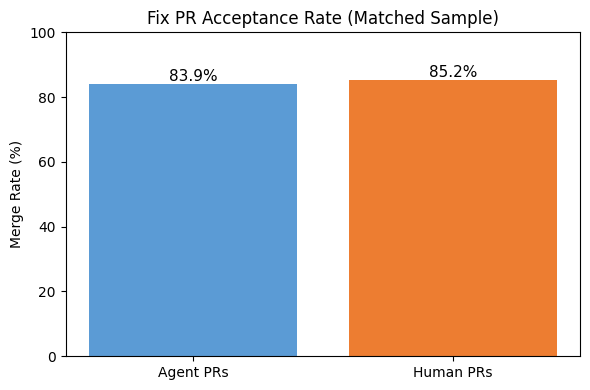


  -> Figure saved: results\matched_report_figures\rq2_merge_rate.png


In [11]:
# Merge rate bar chart
fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(["Agent PRs", "Human PRs"], [apr_r, hpr_r], color=["#5b9bd5", "#ed7d31"])
ax.set_ylabel("Merge Rate (%)")
ax.set_title("Fix PR Acceptance Rate (Matched Sample)")
ax.set_ylim(0, 100)
for bar, val in zip(bars, [apr_r, hpr_r]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, f"{val:.1f}%",
            ha="center", fontsize=11)
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_merge_rate.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq2_merge_rate.png'}")


Agent PRs — median time to merge: 0.50 hours

Human PRs — median time to merge: 5.41 hours


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\2910775606.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_ttm, labels=["APR", "HPR"], patch_artist=True,


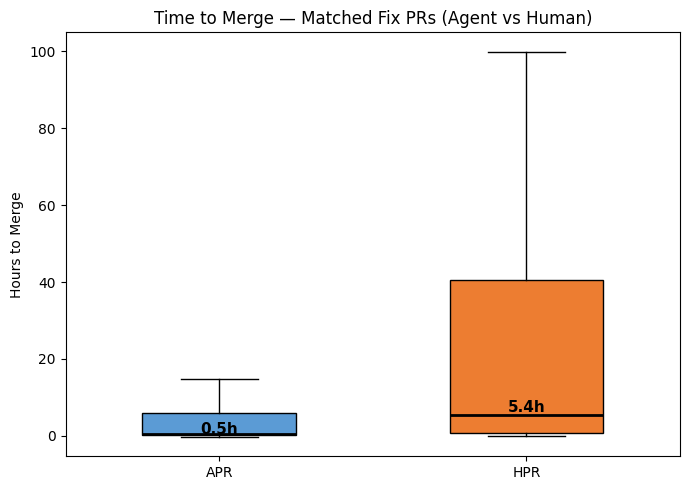

  -> Figure saved: results\matched_report_figures\rq2_time_to_merge.png


In [12]:
# --- Time to merge ---
merge_times = {}
for label, df in [("Agent", agent_prs), ("Human", human_prs)]:
    merged_df = df[df["merged_at"].notna()].copy()
    if len(merged_df) == 0:
        continue
    merged_df["created_dt"] = pd.to_datetime(merged_df["created_at"], utc=True)
    merged_df["merged_dt"] = pd.to_datetime(merged_df["merged_at"], utc=True)
    merged_df["hours_to_merge"] = (merged_df["merged_dt"] - merged_df["created_dt"]).dt.total_seconds() / 3600
    merge_times[label] = merged_df["hours_to_merge"]
    median_h = merged_df["hours_to_merge"].median()
    out(f"\n{label} PRs — median time to merge: {median_h:.2f} hours")

# --- Time to merge box plot ---
fig, ax = plt.subplots(figsize=(7, 5))
data_ttm = [
    merge_times["Agent"].clip(upper=merge_times["Agent"].quantile(0.95)).values,
    merge_times["Human"].clip(upper=merge_times["Human"].quantile(0.95)).values,
]
bp = ax.boxplot(data_ttm, labels=["APR", "HPR"], patch_artist=True,
                widths=0.5, showfliers=False,
                medianprops=dict(color="black", linewidth=2))
bp["boxes"][0].set_facecolor("#5b9bd5")
bp["boxes"][1].set_facecolor("#ed7d31")
for i, vals in enumerate(data_ttm):
    med = np.median(vals)
    ax.text(i + 1, med * 1.15, f"{med:.1f}h", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Hours to Merge")
ax.set_title("Time to Merge — Matched Fix PRs (Agent vs Human)")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_time_to_merge.png", dpi=150)
plt.show()
out(f"  -> Figure saved: {FIG_DIR / 'rq2_time_to_merge.png'}")

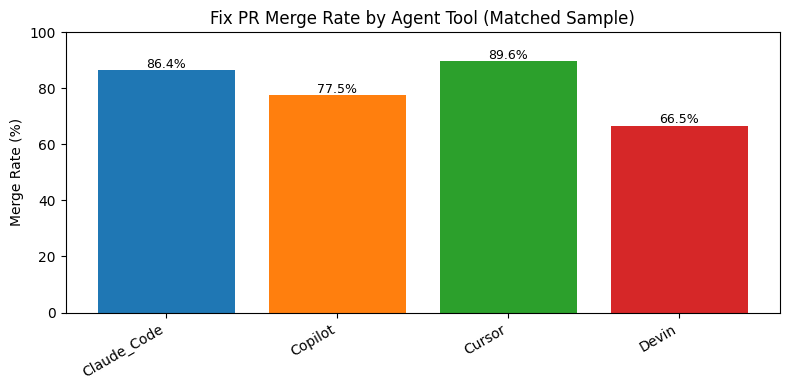

  -> Figure saved: results\matched_report_figures\rq2_merge_rate_by_agent.png


In [13]:
# Merge rate by agent (grouped bar)
if "agent" in agent_prs.columns:
    agent_groups = agent_prs.groupby("agent")
    agents_list = sorted(agent_groups.groups.keys())
    merge_rates = []
    for a in agents_list:
        grp = agent_groups.get_group(a)
        _, _, r = merge_rate(grp)
        merge_rates.append(r)

    fig, ax = plt.subplots(figsize=(8, 4))
    colors = sns.color_palette("tab10", len(agents_list))
    ax.bar(agents_list, merge_rates, color=colors)
    ax.set_ylabel("Merge Rate (%)")
    ax.set_title("Fix PR Merge Rate by Agent Tool (Matched Sample)")
    ax.set_ylim(0, 100)
    for i, (a, r) in enumerate(zip(agents_list, merge_rates)):
        ax.text(i, r + 1, f"{r:.1f}%", ha="center", fontsize=9)
    plt.xticks(rotation=30, ha="right")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq2_merge_rate_by_agent.png", dpi=150)
    plt.show()
    out(f"  -> Figure saved: {FIG_DIR / 'rq2_merge_rate_by_agent.png'}")

C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\3101710130.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  all_prs["created_month_rq2"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")


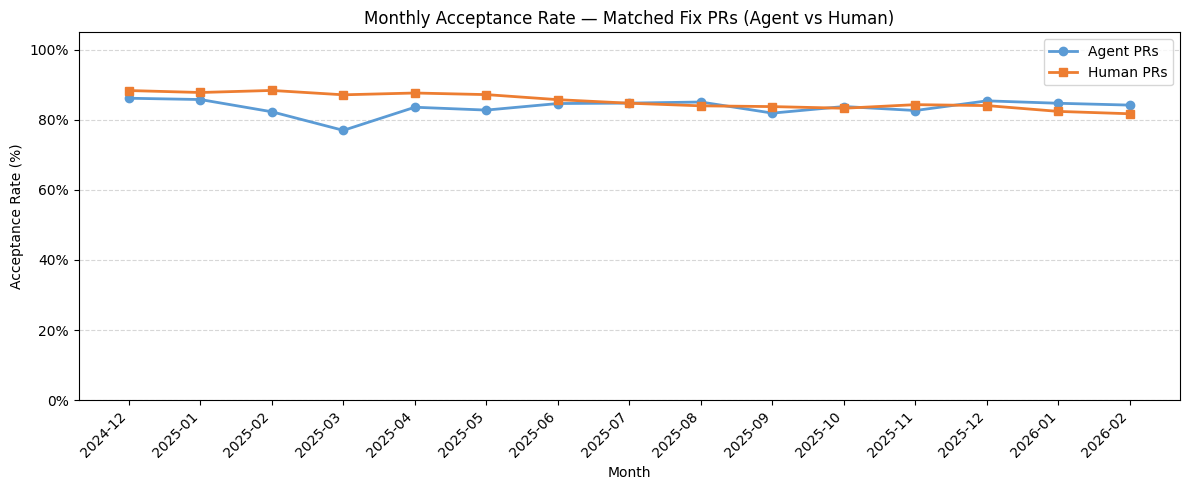


  -> Figure saved: results\matched_report_figures\rq2_monthly_acceptance_rate.png


In [14]:
# ── Figure: Monthly Acceptance Rate — Agent vs Human ──
all_prs["created_month_rq2"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")
all_prs["is_merged"] = all_prs["merged_at"].notna()

monthly_accept = (
    all_prs.groupby(["created_month_rq2", "source"])["is_merged"]
    .agg(["sum", "count"])
    .rename(columns={"sum": "merged", "count": "total"})
    .reset_index()
)
monthly_accept["acceptance_rate"] = monthly_accept["merged"] / monthly_accept["total"] * 100

agent_monthly = monthly_accept[monthly_accept["source"] == "agent"].sort_values("created_month_rq2")
human_monthly = monthly_accept[monthly_accept["source"] == "human"].sort_values("created_month_rq2")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(agent_monthly["created_month_rq2"].astype(str), agent_monthly["acceptance_rate"],
        "o-", label="Agent PRs", color="#5b9bd5", linewidth=2, markersize=6)
ax.plot(human_monthly["created_month_rq2"].astype(str), human_monthly["acceptance_rate"],
        "s-", label="Human PRs", color="#ed7d31", linewidth=2, markersize=6)
ax.set_xlabel("Month")
ax.set_ylabel("Acceptance Rate (%)")
ax.set_title("Monthly Acceptance Rate — Matched Fix PRs (Agent vs Human)")
ax.set_ylim(0, 105)
ax.yaxis.set_major_formatter(mticker.PercentFormatter())
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq2_monthly_acceptance_rate.png", dpi=150, bbox_inches="tight")
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq2_monthly_acceptance_rate.png'}")

In [15]:
# ── Diagnostic: verify monthly acceptance rate numbers ──
print(f"Overall acceptance rates (from RQ2):")
print(f"  Agent: {apr_r:.1f}%  ({apr_m}/{apr_t})")
print(f"  Human: {hpr_r:.1f}%  ({hpr_m}/{hpr_t})")

print(f"\nMonthly breakdown (agent):")
print(agent_monthly[["created_month_rq2", "merged", "total", "acceptance_rate"]].to_string(index=False))

print(f"\nMonthly breakdown (human):")
print(human_monthly[["created_month_rq2", "merged", "total", "acceptance_rate"]].to_string(index=False))

# Sanity check: weighted avg should match overall
agent_weighted = agent_monthly["merged"].sum() / agent_monthly["total"].sum() * 100
human_weighted = human_monthly["merged"].sum() / human_monthly["total"].sum() * 100
print(f"\nWeighted avg from monthly data: Agent={agent_weighted:.1f}%  Human={human_weighted:.1f}%")
print(f"Match overall?  Agent: {'YES' if abs(agent_weighted - apr_r) < 0.1 else 'NO'}  Human: {'YES' if abs(human_weighted - hpr_r) < 0.1 else 'NO'}")

Overall acceptance rates (from RQ2):
  Agent: 83.9%  (97374/116011)
  Human: 85.2%  (98822/116011)

Monthly breakdown (agent):
created_month_rq2  merged  total  acceptance_rate
          2024-12    2520   2924        86.183311
          2025-01    2710   3158        85.813806
          2025-02    3161   3840        82.317708
          2025-03    3738   4854        77.008653
          2025-04    4215   5041        83.614362
          2025-05    6176   7459        82.799303
          2025-06   10778  12729        84.672794
          2025-07   21498  25354        84.791354
          2025-08    9193  10802        85.104610
          2025-09    5836   7123        81.931770
          2025-10    5361   6396        83.818011
          2025-11    5088   6154        82.677933
          2025-12    4969   5816        85.436726
          2026-01    5806   6851        84.746752
          2026-02    6325   7510        84.221039

Monthly breakdown (human):
created_month_rq2  merged  total  acceptance_

C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\3016552386.py:6: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  ).dt.to_period("M")


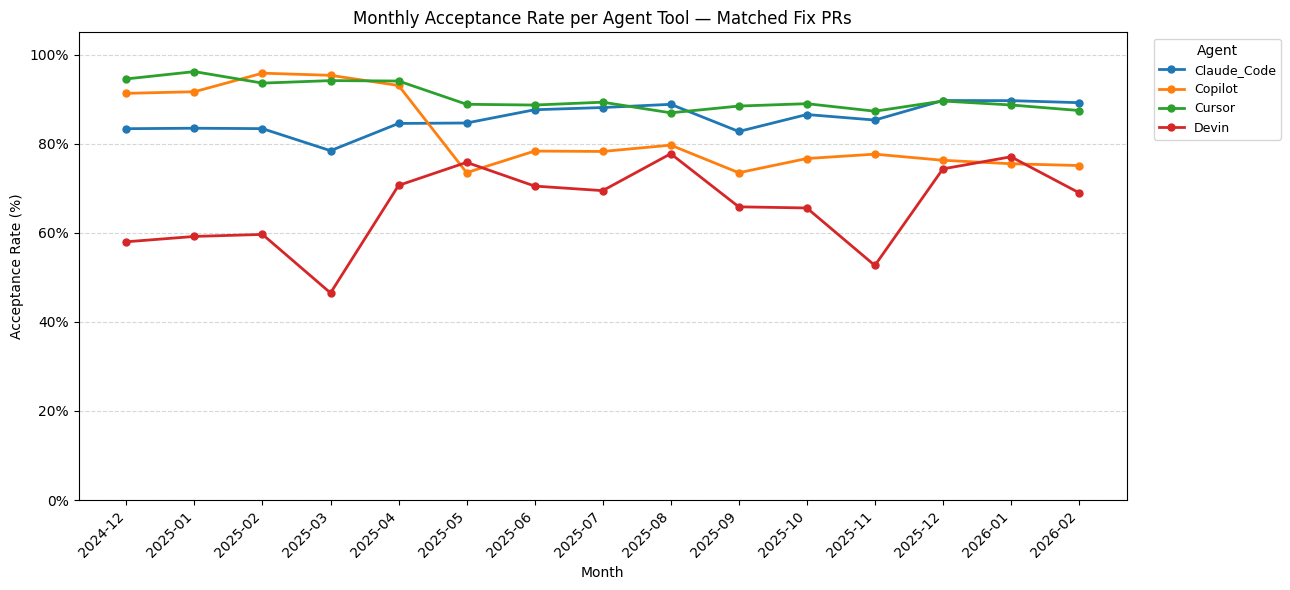


  -> Figure saved: results\matched_report_figures\rq2_monthly_acceptance_rate_per_agent.png


In [16]:
# ── Figure: Monthly Acceptance Rate — Per Agent Tool ──
if "agent" in agent_prs.columns:
    agent_prs_monthly = agent_prs.copy()
    agent_prs_monthly["created_month_rq2"] = pd.to_datetime(
        agent_prs_monthly["created_at"], utc=True
    ).dt.to_period("M")
    agent_prs_monthly["is_merged"] = agent_prs_monthly["merged_at"].notna()

    per_agent_monthly = (
        agent_prs_monthly.groupby(["created_month_rq2", "agent"])["is_merged"]
        .agg(["sum", "count"])
        .rename(columns={"sum": "merged", "count": "total"})
        .reset_index()
    )
    per_agent_monthly["acceptance_rate"] = (
        per_agent_monthly["merged"] / per_agent_monthly["total"] * 100
    )

    agent_names = sorted(per_agent_monthly["agent"].unique())
    palette = sns.color_palette("tab10", len(agent_names))

    fig, ax = plt.subplots(figsize=(13, 6))
    for agent_tool, color in zip(agent_names, palette):
        subset = per_agent_monthly[per_agent_monthly["agent"] == agent_tool].sort_values("created_month_rq2")
        ax.plot(
            subset["created_month_rq2"].astype(str),
            subset["acceptance_rate"],
            "o-", label=agent_tool, color=color, linewidth=2, markersize=5,
        )

    ax.set_xlabel("Month")
    ax.set_ylabel("Acceptance Rate (%)")
    ax.set_title("Monthly Acceptance Rate per Agent Tool — Matched Fix PRs")
    ax.set_ylim(0, 105)
    ax.yaxis.set_major_formatter(mticker.PercentFormatter())
    ax.legend(title="Agent", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
    ax.grid(axis="y", linestyle="--", alpha=0.5)
    plt.xticks(rotation=45, ha="right")
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq2_monthly_acceptance_rate_per_agent.png", dpi=150, bbox_inches="tight")
    plt.show()
    out(f"\n  -> Figure saved: {FIG_DIR / 'rq2_monthly_acceptance_rate_per_agent.png'}")

In [17]:
# ── Table 2 (replication): Acceptance and merge time statistics of PRs ──
#  merged = accepted, closed-but-unmerged = rejected.
# Open PRs already excluded at data loading.

from lifelines.statistics import logrank_test

def compute_row(label, df):
    """Compute stats: merged=accepted, closed-unmerged=rejected."""
    accepted = int(df["merged_at"].notna().sum())
    rejected = int(df["merged_at"].isna().sum())
    total = accepted + rejected
    pct = accepted / total * 100 if total else 0
    merged = df[df["merged_at"].notna()].copy()
    if len(merged):
        merged["hours"] = (
            pd.to_datetime(merged["merged_at"], utc=True)
            - pd.to_datetime(merged["created_at"], utc=True)
        ).dt.total_seconds() / 3600
        med_hours = merged["hours"].median()
    else:
        med_hours = float("nan")
    return [label, f"{accepted:,}", f"{rejected:,}", f"{total:,}", f"{pct:.1f}%", f"{med_hours:.2f}"]

rows = [
    compute_row("APRs", agent_prs),
    compute_row("HPRs", human_prs),
]

# Per-agent breakdown
if "agent" in agent_prs.columns:
    for agent_name in sorted(agent_prs["agent"].unique()):
        rows.append(compute_row(f"  APR \u2013 {agent_name}", agent_prs[agent_prs["agent"] == agent_name]))

summary_df = pd.DataFrame(rows, columns=["Category", "#Accepted", "#Rejected", "#Total", "%Acceptance", "Median Time to Merge"])
print("Table 2. Acceptance and merge time statistics of PRs (Matched Sample).\n")
display(summary_df)

# ── Chi-squared test on acceptance rates ──
apr_acc = int(agent_prs["merged_at"].notna().sum())
apr_rej = int(agent_prs["merged_at"].isna().sum())
hpr_acc = int(human_prs["merged_at"].notna().sum())
hpr_rej = int(human_prs["merged_at"].isna().sum())
contingency = np.array([[apr_acc, apr_rej], [hpr_acc, hpr_rej]])
chi2, p_chi, _, _ = sp_stats.chi2_contingency(contingency)
print(f"\nChi-squared test (acceptance): \u03c7\u00b2={chi2:.2f}, p={p_chi:.6f}")
print(f"  \u2192 {'Statistically significant' if p_chi < 0.05 else 'Not significant'} at \u03b1=0.05")

# ── Log-rank test on merge times ──
def hours_to_merge(df):
    tmp = df.copy()
    tmp["merged"] = tmp["merged_at"].notna().astype(int)
    tmp["hours"] = (
        pd.to_datetime(tmp["closed_at"], utc=True)
        - pd.to_datetime(tmp["created_at"], utc=True)
    ).dt.total_seconds() / 3600
    return tmp["hours"].values, tmp["merged"].values

apr_time, apr_event = hours_to_merge(agent_prs)
hpr_time, hpr_event = hours_to_merge(human_prs)

lr = logrank_test(apr_time, hpr_time, event_observed_A=apr_event, event_observed_B=hpr_event)
print(f"\nLog-rank test (merge time): test_statistic={lr.test_statistic:.2f}, p={lr.p_value:.6f}")
print(f"  \u2192 {'Significant difference' if lr.p_value < 0.05 else 'No significant difference'} in merge times at \u03b1=0.05")

Table 2. Acceptance and merge time statistics of PRs (Matched Sample).



,Category,#Accepted,#Rejected,#Total,%Acceptance,Median Time to Merge
0,APRs,"97,374","18,637","116,011",83.9%,0.50
1,HPRs,"98,822","17,189","116,011",85.2%,5.41
2,APR – Claude_Code,"37,891","5,968","43,859",86.4%,0.64
3,APR – Copilot,"20,664","6,010","26,674",77.5%,0.89
4,APR – Cursor,"33,218","3,837","37,055",89.6%,0.27
5,APR – Devin,"5,601","2,822","8,423",66.5%,0.31



Chi-squared test (acceptance): χ²=69.12, p=0.000000
  → Statistically significant at α=0.05

Log-rank test (merge time): test_statistic=7583.00, p=0.000000
  → Significant difference in merge times at α=0.05


## RQ3 — Revisions

**What proportion of fix PRs are accepted without revisions?**

In [18]:
section("RQ3: What proportion of fix PRs are accepted without revisions?")

# Count commits per PR
commits_per_pr = commits.groupby("pr_id").size().reset_index(name="num_commits")

apr_commits = commits_per_pr[commits_per_pr["pr_id"].isin(agent_ids)]
hpr_commits = commits_per_pr[commits_per_pr["pr_id"].isin(human_ids)]

# Merged PRs only
merged_agent_ids = set(agent_prs[agent_prs["merged_at"].notna()]["id"])
merged_human_ids = set(human_prs[human_prs["merged_at"].notna()]["id"])

apr_merged_commits = apr_commits[apr_commits["pr_id"].isin(merged_agent_ids)]
hpr_merged_commits = hpr_commits[hpr_commits["pr_id"].isin(merged_human_ids)]

apr_single = (apr_merged_commits["num_commits"] == 1).sum()
hpr_single = (hpr_merged_commits["num_commits"] == 1).sum()
apr_total_merged = len(apr_merged_commits)
hpr_total_merged = len(hpr_merged_commits)

apr_single_pct = apr_single / apr_total_merged * 100 if apr_total_merged else 0
hpr_single_pct = hpr_single / hpr_total_merged * 100 if hpr_total_merged else 0

out(f"Merged without revision (single commit):")
out(f"  Agent PRs : {apr_single:,} / {apr_total_merged:,} = {apr_single_pct:.1f}%")
out(f"  Human PRs : {hpr_single:,} / {hpr_total_merged:,} = {hpr_single_pct:.1f}%")

# Revision commit count distribution (for PRs with >1 commit)
apr_revised = apr_merged_commits[apr_merged_commits["num_commits"] > 1]
hpr_revised = hpr_merged_commits[hpr_merged_commits["num_commits"] > 1]

out(f"\nRevised PRs (>1 commit):")
out(f"  Agent PRs : {len(apr_revised):,}  median commits: {apr_revised['num_commits'].median():.0f}" if len(apr_revised) else "  Agent PRs : 0")
out(f"  Human PRs : {len(hpr_revised):,}  median commits: {hpr_revised['num_commits'].median():.0f}" if len(hpr_revised) else "  Human PRs : 0")

# Mann-Whitney U test on revision counts
if len(apr_revised) > 0 and len(hpr_revised) > 0:
    u_stat, p_val = sp_stats.mannwhitneyu(
        apr_revised["num_commits"], hpr_revised["num_commits"], alternative="two-sided"
    )
    out(f"  Mann-Whitney U: U={u_stat:.0f}, p={p_val:.4f}")
    out(f"  {'Statistically significant' if p_val < 0.05 else 'Not statistically significant'} at alpha=0.05")


  RQ3: What proportion of fix PRs are accepted without revisions?
Merged without revision (single commit):
  Agent PRs : 43,018 / 86,676 = 49.6%
  Human PRs : 35,979 / 72,013 = 50.0%

Revised PRs (>1 commit):
  Agent PRs : 43,658  median commits: 3
  Human PRs : 36,034  median commits: 3
  Mann-Whitney U: U=741400826, p=0.0000
  Statistically significant at alpha=0.05


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\2926839412.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data_rev, labels=labels_rev, patch_artist=True,


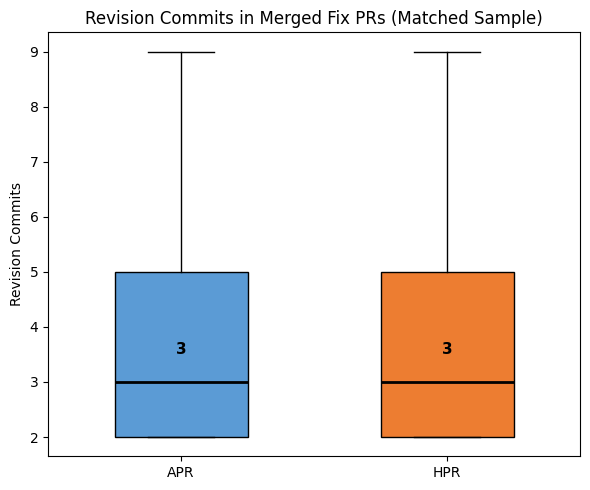


  -> Figure saved: results\matched_report_figures\rq3_revision_commits.png


In [19]:
# Revision count — box plot
fig, ax = plt.subplots(figsize=(6, 5))
data_rev = []
labels_rev = []
if len(apr_revised):
    data_rev.append(apr_revised["num_commits"].clip(upper=50).values)
    labels_rev.append("APR")
if len(hpr_revised):
    data_rev.append(hpr_revised["num_commits"].clip(upper=50).values)
    labels_rev.append("HPR")
if data_rev:
    bp = ax.boxplot(data_rev, labels=labels_rev, patch_artist=True,
                    widths=0.5, showfliers=False,
                    medianprops=dict(color="black", linewidth=2))
    colors = ["#5b9bd5", "#ed7d31"]
    for patch, c in zip(bp["boxes"], colors):
        patch.set_facecolor(c)
    for i, vals in enumerate(data_rev):
        med = np.median(vals)
        ax.text(i + 1, med + 0.5, f"{med:.0f}", ha="center", fontsize=11, fontweight="bold")
ax.set_ylabel("Revision Commits")
ax.set_title("Revision Commits in Merged Fix PRs (Matched Sample)")
fig.tight_layout()
fig.savefig(FIG_DIR / "rq3_revision_commits.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'rq3_revision_commits.png'}")

In [20]:
# Revision change size (files, lines) for revised PRs
# For revised PRs, compute stats from commits after the first one
def initial_and_revision_stats(revised_pr_ids: set, commits_df: pd.DataFrame, details_df: pd.DataFrame):
    """Get change stats for initial commit and revision commits separately."""
    pr_commits_ordered = commits_df[commits_df["pr_id"].isin(revised_pr_ids)].copy()
    first_commits = pr_commits_ordered.groupby("pr_id").first().reset_index()
    first_shas = set(first_commits["sha"])

    # Initial commit stats
    init_details = details_df[details_df["sha"].isin(first_shas)]
    init_stats = init_details.groupby("pr_id").agg(
        init_files=("filename", "nunique"),
        init_added=("additions", "sum"),
        init_deleted=("deletions", "sum"),
    ).reset_index()
    init_stats["init_total_changes"] = init_stats["init_added"] + init_stats["init_deleted"]

    # Revision commit stats (all non-first commits)
    rev_shas = set(pr_commits_ordered["sha"]) - first_shas
    rev_details = details_df[details_df["sha"].isin(rev_shas)]
    rev_stats = rev_details.groupby("pr_id").agg(
        rev_files_changed=("filename", "nunique"),
        rev_lines_added=("additions", "sum"),
        rev_lines_deleted=("deletions", "sum"),
    ).reset_index()
    rev_stats["rev_total_changes"] = rev_stats["rev_lines_added"] + rev_stats["rev_lines_deleted"]

    # Merge and compute metric (4): % of code modification vs initial submission
    merged = rev_stats.merge(init_stats[["pr_id", "init_total_changes"]], on="pr_id", how="left")
    merged["pct_modification"] = (
        merged["rev_total_changes"] / merged["init_total_changes"].replace(0, np.nan) * 100
    )
    return merged

apr_rev_ids = set(apr_revised["pr_id"])
hpr_rev_ids = set(hpr_revised["pr_id"])

if apr_rev_ids or hpr_rev_ids:
    apr_rev_stats = initial_and_revision_stats(apr_rev_ids, commits, details) if apr_rev_ids else pd.DataFrame()
    hpr_rev_stats = initial_and_revision_stats(hpr_rev_ids, commits, details) if hpr_rev_ids else pd.DataFrame()

    out("\nRevision effort (median, revised PRs only):")
    out("  Metric (2) - Files changed in revisions:")
    a_med = apr_rev_stats["rev_files_changed"].median() if len(apr_rev_stats) else 0
    h_med = hpr_rev_stats["rev_files_changed"].median() if len(hpr_rev_stats) else 0
    out(f"    APR: {a_med:.0f}   HPR: {h_med:.0f}")

    out("  Metric (3) - Lines added/deleted in revisions:")
    for metric in ["rev_lines_added", "rev_lines_deleted"]:
        a_med = apr_rev_stats[metric].median() if len(apr_rev_stats) else 0
        h_med = hpr_rev_stats[metric].median() if len(hpr_rev_stats) else 0
        out(f"    {metric:<25s}  APR: {a_med:>8.0f}   HPR: {h_med:>8.0f}")

    out("  Metric (4) - % code modification vs initial submission:")
    a_pct = apr_rev_stats["pct_modification"].median() if len(apr_rev_stats) else 0
    h_pct = hpr_rev_stats["pct_modification"].median() if len(hpr_rev_stats) else 0
    out(f"    APR: {a_pct:.1f}%   HPR: {h_pct:.1f}%")


Revision effort (median, revised PRs only):
  Metric (2) - Files changed in revisions:
    APR: 3   HPR: 2
  Metric (3) - Lines added/deleted in revisions:
    rev_lines_added            APR:       44   HPR:       10
    rev_lines_deleted          APR:       15   HPR:        6
  Metric (4) - % code modification vs initial submission:
    APR: 100.0%   HPR: 81.2%


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\1453451127.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\1453451127.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\1453451127.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,


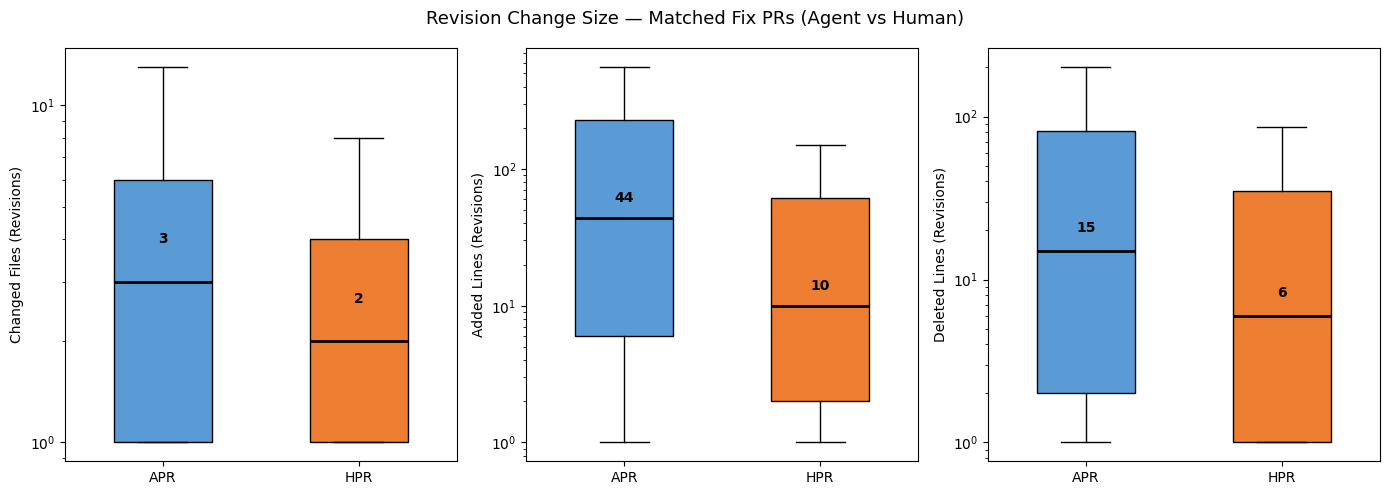

  -> Figure saved: results\matched_report_figures\rq3_revision_change_size.png


In [21]:
# Revision change size — box plots on log scale
if apr_rev_ids or hpr_rev_ids:
    fig, axes = plt.subplots(1, 3, figsize=(14, 5))
    rev_metrics = ["rev_files_changed", "rev_lines_added", "rev_lines_deleted"]
    rev_titles = ["Changed Files (Revisions)", "Added Lines (Revisions)", "Deleted Lines (Revisions)"]
    for ax, metric, title in zip(axes, rev_metrics, rev_titles):
        apr_vals = apr_rev_stats[metric].dropna().clip(lower=1).values if len(apr_rev_stats) else np.array([])
        hpr_vals = hpr_rev_stats[metric].dropna().clip(lower=1).values if len(hpr_rev_stats) else np.array([])
        data = [apr_vals, hpr_vals]
        bp = ax.boxplot(data, labels=["APR", "HPR"], patch_artist=True,
                        widths=0.5, showfliers=False,
                        medianprops=dict(color="black", linewidth=2))
        bp["boxes"][0].set_facecolor("#5b9bd5")
        bp["boxes"][1].set_facecolor("#ed7d31")
        ax.set_yscale("log")
        ax.set_ylabel(title)
        for i, vals in enumerate(data):
            if len(vals):
                med = np.median(vals)
                ax.text(i + 1, med * 1.3, f"{med:.0f}", ha="center", fontsize=10, fontweight="bold")
    fig.suptitle("Revision Change Size — Matched Fix PRs (Agent vs Human)", fontsize=13)
    fig.tight_layout()
    fig.savefig(FIG_DIR / "rq3_revision_change_size.png", dpi=150, bbox_inches="tight")
    plt.show()
    out(f"  -> Figure saved: {FIG_DIR / 'rq3_revision_change_size.png'}")

## Additional Statistics

In [22]:
section("Additional Statistics")

# PR state breakdown
out("PR state breakdown:")
for label, df in [("Agent", agent_prs), ("Human", human_prs)]:
    out(f"  {label}:")
    for state, cnt in df["state"].value_counts().items():
        out(f"    {state:12s} {cnt:>8,}")


  Additional Statistics
PR state breakdown:
  Agent:
    closed        116,011
  Human:
    closed        116,011


In [23]:
# Monthly trends
all_prs["created_month"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")
monthly = all_prs.groupby(["created_month", "is_agent"]).size().unstack(fill_value=0)
monthly.columns = ["Human", "Agent"] if False in monthly.columns else monthly.columns

out("\nMonthly PR volume:")
out(f"{'Month':<12} {'Agent':>8} {'Human':>8} {'Total':>8}")
out("-" * 40)
for period in monthly.index:
    row = monthly.loc[period]
    agent_val = row.get(True, row.get("Agent", 0))
    human_val = row.get(False, row.get("Human", 0))
    total = agent_val + human_val
    out(f"{str(period):<12} {int(agent_val):>8,} {int(human_val):>8,} {int(total):>8,}")


Monthly PR volume:
Month           Agent    Human    Total
----------------------------------------
2024-12         2,924    5,766    8,690
2025-01         3,158    6,463    9,621
2025-02         3,840    6,954   10,794
2025-03         4,854    7,626   12,480
2025-04         5,041    7,635   12,676
2025-05         7,459    7,386   14,845
2025-06        12,729    7,607   20,336
2025-07        25,354    8,630   33,984
2025-08        10,802    7,557   18,359
2025-09         7,123    7,980   15,103
2025-10         6,396    8,354   14,750
2025-11         6,154    7,713   13,867
2025-12         5,816    7,841   13,657
2026-01         6,851    8,949   15,800
2026-02         7,510    9,550   17,060


C:\Users\Mahmoudabujadallah\AppData\Local\Temp\ipykernel_30816\259854839.py:2: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  all_prs["created_month"] = pd.to_datetime(all_prs["created_at"], utc=True).dt.to_period("M")


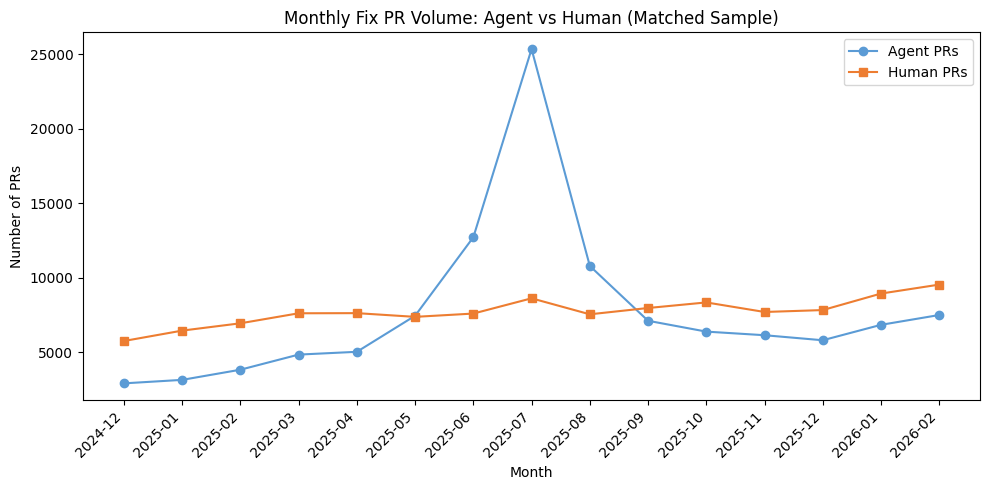


  -> Figure saved: results\matched_report_figures\monthly_trend.png


In [24]:
# Monthly trend chart
fig, ax = plt.subplots(figsize=(10, 5))
months_str = [str(p) for p in monthly.index]
agent_vals = [monthly.loc[p].get(True, monthly.loc[p].get("Agent", 0)) for p in monthly.index]
human_vals = [monthly.loc[p].get(False, monthly.loc[p].get("Human", 0)) for p in monthly.index]
ax.plot(months_str, agent_vals, "o-", label="Agent PRs", color="#5b9bd5")
ax.plot(months_str, human_vals, "s-", label="Human PRs", color="#ed7d31")
ax.set_xlabel("Month")
ax.set_ylabel("Number of PRs")
ax.set_title("Monthly Fix PR Volume: Agent vs Human (Matched Sample)")
ax.legend()
plt.xticks(rotation=45, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "monthly_trend.png", dpi=150)
plt.show()
out(f"\n  -> Figure saved: {FIG_DIR / 'monthly_trend.png'}")

In [25]:
# Top repositories
out("\nTop 10 repos by total PRs:")
top_repos = all_prs["repo_name"].value_counts().head(10)
for repo, cnt in top_repos.items():
    agent_cnt = len(all_prs[(all_prs["repo_name"] == repo) & (all_prs["is_agent"] == True)])
    out(f"  {repo:50s}  total: {cnt:>5,}  agent: {agent_cnt:>5,}")


Top 10 repos by total PRs:
  getsentry/sentry                                    total: 3,941  agent: 1,566
  PostHog/posthog                                     total: 3,320  agent:   134
  StarRocks/starrocks                                 total: 3,290  agent:   162
  elastic/kibana                                      total: 3,269  agent:    73
  BerriAI/litellm                                     total: 2,227  agent: 1,159
  Expensify/App                                       total: 2,101  agent:     2
  vllm-project/vllm                                   total: 2,081  agent:    19
  microsoft/vscode                                    total: 1,930  agent:   468
  pytorch/pytorch                                     total: 1,757  agent:     9
  MetaMask/metamask-mobile                            total: 1,736  agent:   150


## Save Report

In [26]:
REPORT_PATH.write_text("\n".join(report_lines), encoding="utf-8")
print(f"\nReport saved to {REPORT_PATH}")
print(f"Figures saved to {FIG_DIR}/")
print("Done!")


Report saved to results\matched_report.txt
Figures saved to results\matched_report_figures/
Done!
